# Ethics Data Privacy Project
### By Jennifer Panula

### Coding was performed with significant assistance from ChatGPT

In [1]:
import os
import re
import spacy
import pandas as pd
import matplotlib.pyplot as plt

nlp = spacy.load("en_core_web_sm")

In [2]:
#broder keywords to avoid missing anything
DETAILED_FEATURES = {
    # 🔹 Data Collection
    "types_of_data": [
        "personal", "information", "email", "name", "address", "phone",
        "location", "ip", "device", "identifier", "usage", "activity"
    ],
    
    "collection_methods": [
        "collect", "gather", "receive", "obtain", "automatically",
        "cookies", "tracking", "log", "analytics", "beacon", "pixel"
    ],
    
    "purpose_specification": [
        "use", "purpose", "provide", "improve", "analyze",
        "marketing", "advertising", "security", "service", "operate"
    ],
    
    # 🔹 User Rights
    "access_rights": [
        "access", "request", "view", "obtain copy", "right to know"
    ],
    
    "deletion_rights": [
        "delete", "erase", "remove", "right to be forgotten"
    ],
    
    "portability": [
        "portability", "transfer your data", "download your data"
    ],
    
    "opt_out_mechanisms": [
        "opt out", "unsubscribe", "withdraw", "do not sell",
        "preferences", "settings", "choices"
    ],
    
    # 🔹 Data Sharing
    "third_party_sharing": [
        "third party", "third-party", "partners", "affiliates",
        "share", "disclose", "provide to", "vendors"
    ],
    
    "international_transfers": [
        "international", "transfer", "outside", "cross-border",
        "global", "other countries"
    ],
    
    "service_providers": [
        "service provider", "processor", "contractor",
        "vendor", "business partner"
    ],
    
    # 🔹 Security
    "storage_practices": [
        "retain", "store", "storage", "keep", "retention"
    ],
    
    "protection_methods": [
        "security", "protect", "encryption", "safeguard",
        "measures", "secure"
    ],
    
    "breach_notification": [
        "breach", "incident", "unauthorized access",
        "notify", "notification"
    ]
}

In [3]:
def match_keywords(sentence, keywords):
    sentence = sentence.lower()
    
    matches = 0
    
    for kw in keywords:
        pattern = r"\b" + re.escape(kw) + r"\b"
        if re.search(pattern, sentence):
            matches += 1
    
    return matches

In [4]:
def extract_features(text):
    doc = nlp(text)
    
    results = {key: [] for key in DETAILED_FEATURES}
    
    for sent in doc.sents:
        sent_text = sent.text.strip()
        
        for feature, keywords in DETAILED_FEATURES.items():
            match_count = match_keywords(sent_text, keywords)
            
            if match_count > 0:
                results[feature].append(sent_text)
    
    return results

In [5]:
def process_files(data_folder="data"):
    all_rows = []
    
    for file in os.listdir(data_folder):
        if file.endswith(".txt"):
            with open(os.path.join(data_folder, file), "r", encoding="utf-8") as f:
                text = f.read()
            
            extracted = extract_features(text)
            
            row = {"Service": file}
            
            for feature in DETAILED_FEATURES:
                row[feature] = " | ".join(extracted[feature][:5])  # keep top 5
            
            all_rows.append(row)
    
    return pd.DataFrame(all_rows)

df = process_files()

In [6]:
pd.set_option('display.max_colwidth', None)
df.head(2)

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification
0,discover_privacy.txt,"Discover Consumer Privacy Notice\nFACTS\nWHAT DOES DISCOVER \nDO WITH YOUR PERSONAL INFORMATION? | Rev. 10/25\n\nWhy?\tFinancial companies choose how they share your personal information. | Federal law also requires us to tell you how we collect, share, and protect your personal information. | What?\tThe types of personal information we collect and share depend on the product or service you have with us. | This information can include:\n\nSocial Security number and account transactions.","Federal law also requires us to tell you how we collect, share, and protect your personal information. | What?\tThe types of personal information we collect and share depend on the product or service you have with us. | How does Discover collect my personal information? | We collect your personal information, for example, when you:\n\nOpen an account or make deposits or withdrawals from your account. | We also collect your personal information from others, such as credit bureaus and other consumer reporting agencies, affiliates, or other companies.","What?\tThe types of personal information we collect and share depend on the product or service you have with us. | This information can include:\n\nSocial Security number and account transactions. | For our everyday business purposes—such as to process your transactions, maintain your account(s), respond to court orders and legal investigations, or report to credit bureaus and other consumer reporting agencies\tYes\tNo\nFor our marketing purposes—to offer our products and services to you\tYes\tNo\nFor joint marketing with other financial companies\tYes\tNo\nFor our affiliates' everyday business purposes—information about your transactions and experiences\tYes\tNo\nFor our affiliates' everyday business purposes—information about your creditworthiness\tYes\tYes\nFor our affiliates to market to you | To protect your personal information from unauthorized access and use, we use security measures that comply with federal law. | Provide account information.","To protect your personal information from unauthorized access and use, we use security measures that comply with federal law.",,,"For nonaffiliates to market to you\tNo\tWe don't share\nTo limit our sharing\t■ Call 1-866-402-1048 – our menu will prompt you through your choices\n\nPlease note:\nIf you are a new customer, we can begin sharing your information 30 days from the date we sent this notice. | Your choices will apply to everyone on your account.","Rev. 10/25\n\nWhy?\tFinancial companies choose how they share your personal information. | Federal law also requires us to tell you how we collect, share, and protect your personal information. | What?\tThe types of personal information we collect and share depend on the product or service you have with us. | How?\tAll financial companies need to share customers' personal information to run their everyday business. | In the section below, we list the reasons financial companies can share their customers' personal information; the reasons Discover chooses to share; and whether you can limit this sharing.","Give us your contact information or make a wire transfer. | Our affiliates include financial companies with the Capital One, Capital One Shopping, Discover, DFS, Velocity Black, Diners Club International, PULSE Network, and The Student Loan Corporation names.",,,"Federal law also requires us to tell you how we collect, share, and protect your personal information. | This information can include:\n\nSocial Security number and account transactions. | What we do\nHow does Discover protect my personal information? | To protect your personal information from unauthorized access and use, we use security measures that comply with federal l

In [7]:
def check_detailed(text):
    if not isinstance(text, str) or text.strip() == "":
        return "No"
    
    word_count = len(text.split())
    
    if word_count < 15:
        return "Partial"
    else:
        return "Yes"

In [8]:
df_matrix = pd.DataFrame()
df_matrix["Service"] = df["Service"]

for col in DETAILED_FEATURES:
    df_matrix[col] = df[col].apply(check_detailed)

In [9]:
def get_word_count(filename, data_folder="data"):
    try:
        with open(f"{data_folder}/{filename}", "r", encoding="utf-8") as f:
            text = f.read()
            return len(text.split())
    except:
        return None

In [10]:
df_matrix["Word Count"] = df_matrix["Service"].apply(get_word_count)

In [11]:
df_matrix

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Word Count
0,discover_privacy.txt,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,Yes,Yes,854
1,Meta_privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,20843
2,microsoft_privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Partial,4444
3,netflix_privacy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10494
4,openAI_privacy.txt,Yes,Yes,Yes,Yes,Yes,Partial,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4277
5,robinhood_privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,5541
6,spotify_privacy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,6347
7,uber_privacy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,8062


In [12]:
df_matrix[["Service", "Word Count"]]

,Service,Word Count
0,discover_privacy.txt,854
1,Meta_privacy.txt,20843
2,microsoft_privacy.txt,4444
3,netflix_privacy.txt,10494
4,openAI_privacy.txt,4277
5,robinhood_privacy.txt,5541
6,spotify_privacy.txt,6347
7,uber_privacy.txt,8062


In [13]:
score_map = {"No": 0, "Partial": 1, "Yes": 2}

df_numeric = df_matrix.replace(score_map)
df_numeric

C:\Users\jenpa\AppData\Local\Temp\ipykernel_31112\3498711354.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_matrix.replace(score_map)


,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Word Count
0,discover_privacy.txt,2,2,2,2,0,0,2,2,2,0,0,2,2,854
1,Meta_privacy.txt,2,2,2,2,2,0,2,2,2,2,2,2,2,20843
2,microsoft_privacy.txt,2,2,2,2,2,0,2,2,0,2,2,2,1,4444
3,netflix_privacy.txt,2,2,2,2,2,2,2,2,2,2,2,2,2,10494
4,openAI_privacy.txt,2,2,2,2,2,1,2,2,2,2,2,2,2,4277
5,robinhood_privacy.txt,2,2,2,2,2,0,2,2,2,2,2,2,2,5541
6,spotify_privacy.txt,2,2,2,2,2,2,2,2,2,2,2,2,2,6347
7,uber_privacy.txt,2,2,2,2,2,2,2,2,2,2,2,2,2,8062


In [14]:
df_matrix["Total Score"] = df_numeric.drop(
    columns=["Service", "Word Count"]
).sum(axis=1)

In [15]:
df_matrix['Total Score']

0    18
1    24
2    21
3    26
4    25
5    24
6    26
7    26
Name: Total Score, dtype: int64

In [16]:
REG_MAP = {
    # CCPA
    "ccpa_access": ["access_rights"],
    "ccpa_deletion": ["deletion_rights"],
    "ccpa_opt_out": ["opt_out_mechanisms"],
    "ccpa_notice": ["types_of_data", "purpose_specification"],
    
    # VCDPA
    "vcdpa_rights": ["access_rights", "deletion_rights", "portability"],
    "vcdpa_processing": ["purpose_specification"],
    "vcdpa_security": ["protection_methods"],
    
    # GDPR
    "gdpr_rights": ["access_rights", "deletion_rights", "portability"],
    "gdpr_consent_like": ["opt_out_mechanisms"],  # proxy
    "gdpr_transfer": ["international_transfers"],
    "gdpr_security": ["protection_methods"],
}

In [17]:
df_reg = pd.DataFrame()
df_reg["Service"] = df_matrix["Service"]

for reg, features in REG_MAP.items():
    df_reg[reg] = df_numeric[features].mean(axis=1)

In [18]:
df_reg

,Service,ccpa_access,ccpa_deletion,ccpa_opt_out,ccpa_notice,vcdpa_rights,vcdpa_processing,vcdpa_security,gdpr_rights,gdpr_consent_like,gdpr_transfer,gdpr_security
0,discover_privacy.txt,2.0,0.0,2.0,2.0,0.666667,2.0,2.0,0.666667,2.0,2.0,2.0
1,Meta_privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0
2,microsoft_privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,0.0,2.0
3,netflix_privacy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0
4,openAI_privacy.txt,2.0,2.0,2.0,2.0,1.666667,2.0,2.0,1.666667,2.0,2.0,2.0
5,robinhood_privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0
6,spotify_privacy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0
7,uber_privacy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0


In [19]:
df_reg["CCPA_score"] = df_reg[
    ["ccpa_access", "ccpa_deletion", "ccpa_opt_out", "ccpa_notice"]
].mean(axis=1)

df_reg["VCDPA_score"] = df_reg[
    ["vcdpa_rights", "vcdpa_processing", "vcdpa_security"]
].mean(axis=1)

df_reg["GDPR_score"] = df_reg[
    ["gdpr_rights", "gdpr_consent_like", "gdpr_transfer", "gdpr_security"]
].mean(axis=1)

In [20]:
def label_compliance(score):
    if score >= 1.5:
        return "Strong"
    elif score >= 0.75:
        return "Moderate"
    else:
        return "Weak"

df_reg["CCPA_level"] = df_reg["CCPA_score"].apply(label_compliance)
df_reg["VCDPA_level"] = df_reg["VCDPA_score"].apply(label_compliance)
df_reg["GDPR_level"] = df_reg["GDPR_score"].apply(label_compliance)

In [21]:
df_reg

,Service,ccpa_access,ccpa_deletion,ccpa_opt_out,ccpa_notice,vcdpa_rights,vcdpa_processing,vcdpa_security,gdpr_rights,gdpr_consent_like,gdpr_transfer,gdpr_security,CCPA_score,VCDPA_score,GDPR_score,CCPA_level,VCDPA_level,GDPR_level
0,discover_privacy.txt,2.0,0.0,2.0,2.0,0.666667,2.0,2.0,0.666667,2.0,2.0,2.0,1.5,1.555556,1.666667,Strong,Strong,Strong
1,Meta_privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0,2.0,1.777778,1.833333,Strong,Strong,Strong
2,microsoft_privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,0.0,2.0,2.0,1.777778,1.333333,Strong,Strong,Moderate
3,netflix_privacy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0,2.0,2.000000,2.000000,Strong,Strong,Strong
4,openAI_privacy.txt,2.0,2.0,2.0,2.0,1.666667,2.0,2.0,1.666667,2.0,2.0,2.0,2.0,1.888889,1.916667,Strong,Strong,Strong
5,robinhood_privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0,2.0,1.777778,1.833333,Strong,Strong,Strong
6,spotify_privacy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0,2.0,2.000000,2.000000,Strong,Strong,Strong
7,uber_privacy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0,2.0,2.000000,2.000000,Strong,Strong,Strong


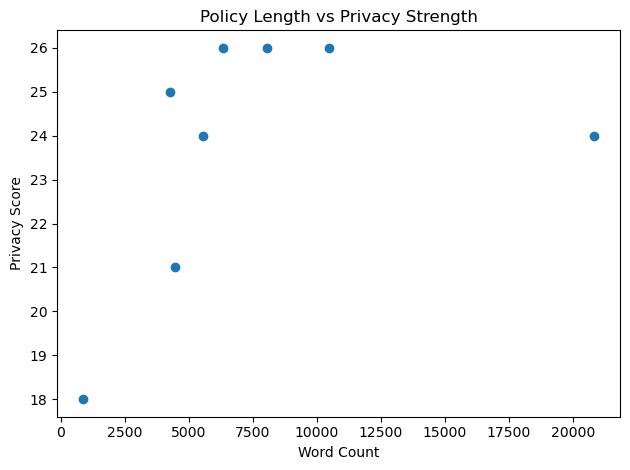

In [22]:
plt.figure()
plt.scatter(df_matrix["Word Count"], df_matrix["Total Score"])

plt.xlabel("Word Count")
plt.ylabel("Privacy Score")
plt.title("Policy Length vs Privacy Strength")

plt.tight_layout()
plt.show()

In [23]:
max_score = len(df_numeric.columns[1:]) * 2

df_matrix["Normalized Score"] = df_matrix["Total Score"] / max_score

In [24]:
def performance_label(score):
    if score >= 0.75:
        return "Best Practice"
    elif score >= 0.5:
        return "Average"
    else:
        return "Needs Improvement"

df_matrix["Performance"] = df_matrix["Normalized Score"].apply(performance_label)
df_matrix

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Word Count,Total Score,Normalized Score,Performance
0,discover_privacy.txt,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,Yes,Yes,854,18,0.642857,Average
1,Meta_privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,20843,24,0.857143,Best Practice
2,microsoft_privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Partial,4444,21,0.750000,Best Practice
3,netflix_privacy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10494,26,0.928571,Best Practice
4,openAI_privacy.txt,Yes,Yes,Yes,Yes,Yes,Partial,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4277,25,0.892857,Best Practice
5,robinhood_privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,5541,24,0.857143,Best Practice
6,spotify_privacy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,6347,26,0.928571,Best Practice
7,uber_privacy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,8062,26,0.928571,Best Practice


In [25]:
feature_presence = (df_numeric.iloc[:, 1:] >= 1).sum()
num_services = len(df_numeric)

In [26]:
common = feature_presence[feature_presence == num_services].index.tolist()
rare = feature_presence[feature_presence <= 1].index.tolist()
moderate = [
    f for f in feature_presence.index
    if f not in common and f not in rare
]

In [27]:
df_features = pd.DataFrame({
    "Feature": feature_presence.index,
    "Count": feature_presence.values
})

def classify_feature(count):
    if count == num_services:
        return "Common"
    elif count <= 1:
        return "Rare"
    else:
        return "Moderate"

df_features["Category"] = df_features["Count"].apply(classify_feature)
df_features

,Feature,Count,Category
0,types_of_data,8,Common
1,collection_methods,8,Common
2,purpose_specification,8,Common
3,access_rights,8,Common
4,deletion_rights,7,Moderate
5,portability,4,Moderate
6,opt_out_mechanisms,8,Common
7,third_party_sharing,8,Common
8,international_transfers,7,Moderate
9,service_providers,7,Moderate


In [28]:
unique_map = {}

for col in df_numeric.columns[1:]:
    services = df_matrix.loc[df_numeric[col] >= 1, "Service"]
    
    if len(services) == 1:
        unique_map[col] = services.iloc[0]

unique_map

{}

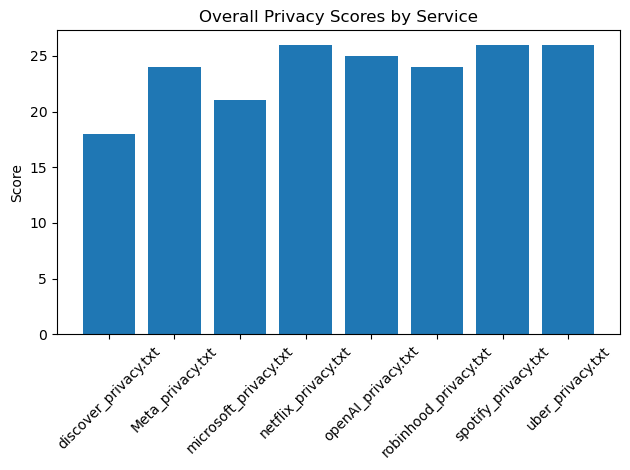

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_matrix["Service"], df_matrix["Total Score"])

plt.xticks(rotation=45)
plt.title("Overall Privacy Scores by Service")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

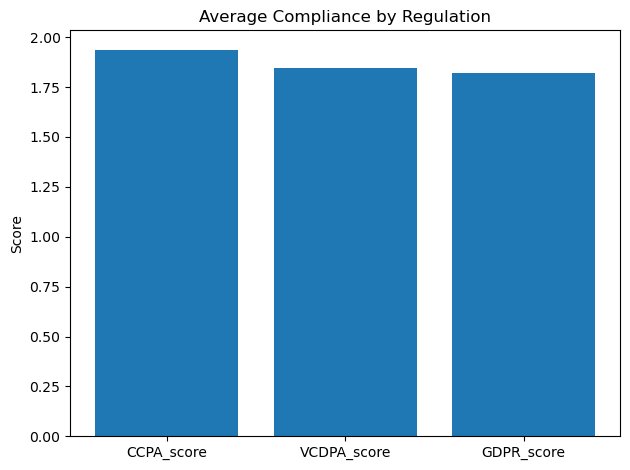

In [30]:
law_scores = df_reg[["CCPA_score", "VCDPA_score", "GDPR_score"]]

plt.figure()
plt.bar(law_scores.columns, law_scores.mean())

plt.title("Average Compliance by Regulation")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

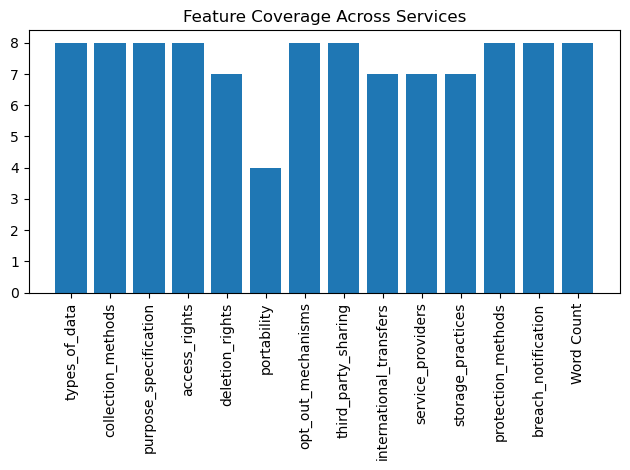

In [31]:
plt.figure()
plt.bar(df_features["Feature"], df_features["Count"])

plt.xticks(rotation=90)
plt.title("Feature Coverage Across Services")

plt.tight_layout()
plt.show()